In [15]:
import seaborn as sns

In [12]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt


In [78]:
import psycopg2

# Connect to your PostgreSQL database
conn = psycopg2.connect(
    dbname="dwh",
    user="postgres",
    password="123",
    host="localhost",
    port="5432"
)
try:
    # Execute a query to select data from a table
    query = "SELECT * FROM cust_report.tbl_aggr_total_orders_daily_summary"
    df = pd.read_sql_query(query, conn)
    
    # Print the DataFrame
   # print(df)
        
except (Exception, psycopg2.DatabaseError) as error:
    print("Error fetching data:", error)

finally:
    # Close the connection
    conn.close()


/var/folders/mm/5jv3lmt93yd4f1nkxw3yxcv80000gp/T/ipykernel_72268/3602419672.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [11]:
df.head()

,created_at,order_status,total_order
0,2022-08-10,Cancelled,2
1,2022-08-10,Completed,15
2,2022-08-09,Cancelled,6
3,2022-08-09,Completed,15
4,2022-08-08,Cancelled,7


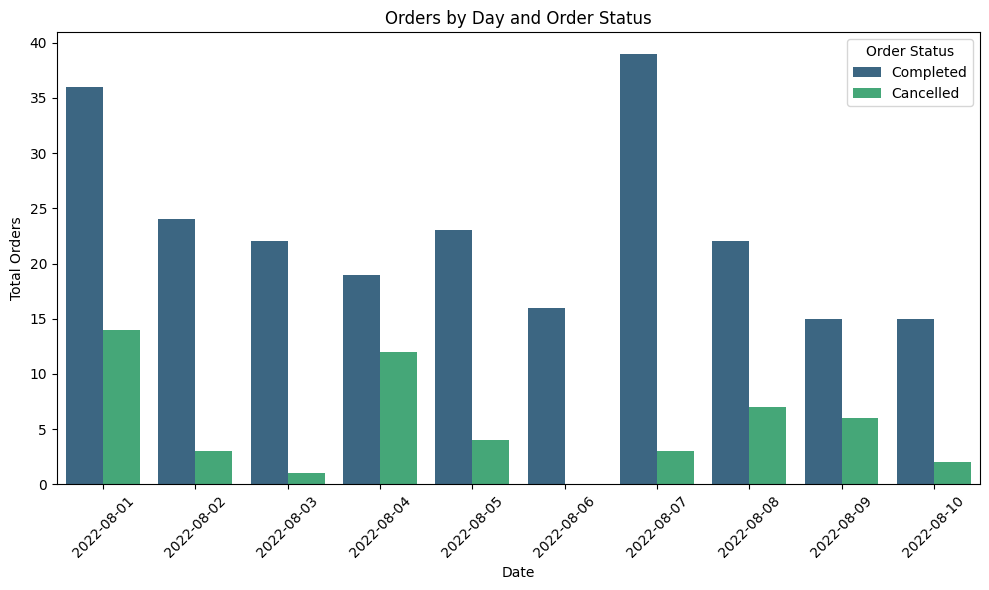

In [80]:
# Plotting
df_count = df.sort_values(by='created_at')
plt.figure(figsize=(10, 6))
sns.barplot(data=df_count, x='created_at', y='total_order', hue='order_status', palette='viridis')
plt.title('Orders by Day and Order Status')
plt.xlabel('Date')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()

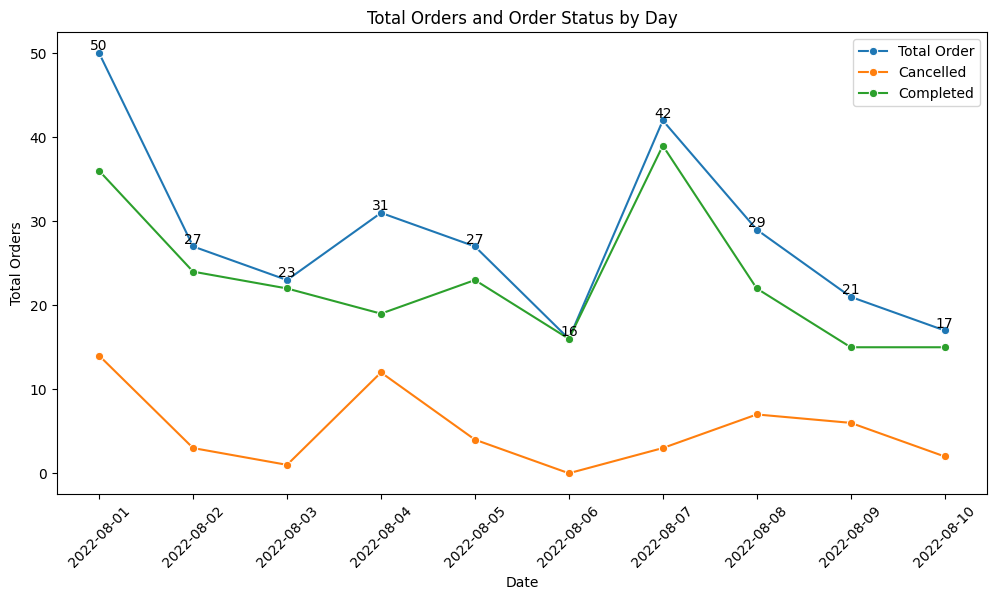

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a dataframe named 'df' with columns 'created_at', 'order_status', and 'total_order'
# Convert 'created_at' to datetime
# df['created_at'] = pd.to_datetime(df['created_at'])

# Group the data by day and calculate total orders for each day
daily_total_orders = df.groupby(pd.Grouper(key='created_at', freq='D')).sum().reset_index()

# Plotting using seaborn
plt.figure(figsize=(12, 6))

# Plot total order
sns.lineplot(data=daily_total_orders, x='created_at', y='total_order', label='Total Order', marker='o')

# Add value labels for each data point along the total order line
for index, row in daily_total_orders.iterrows():
    plt.text(row['created_at'], row['total_order'], str(int(row['total_order'])), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Total Orders')
plt.title('Total Orders and Order Status by Day')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Plot order status lines
for status in df['order_status'].unique():
    status_data = df[df['order_status'] == status].groupby(pd.Grouper(key='created_at', freq='D')).sum().reset_index()
    sns.lineplot(data=status_data, x='created_at', y='total_order', label=status, marker='o')

# Show the legend
plt.legend()

# Show the chart
plt.show()


### Margin plotting

In [73]:
import psycopg2

# Connect to your PostgreSQL database
conn = psycopg2.connect(
    dbname="dwh",
    user="postgres",
    password="123",
    host="localhost",
    port="5432"
)
try:
    # Execute a query to select data from a table
    query = "SELECT * FROM cust_report.tbl_aggr_margin_daily_summary"
    df_margin = pd.read_sql_query(query, conn)
    
    # Print the DataFrame
   # print(df)
        
except (Exception, psycopg2.DatabaseError) as error:
    print("Error fetching data:", error)

finally:
    # Close the connection
    conn.close()


/var/folders/mm/5jv3lmt93yd4f1nkxw3yxcv80000gp/T/ipykernel_72268/377380050.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_margin = pd.read_sql_query(query, conn)


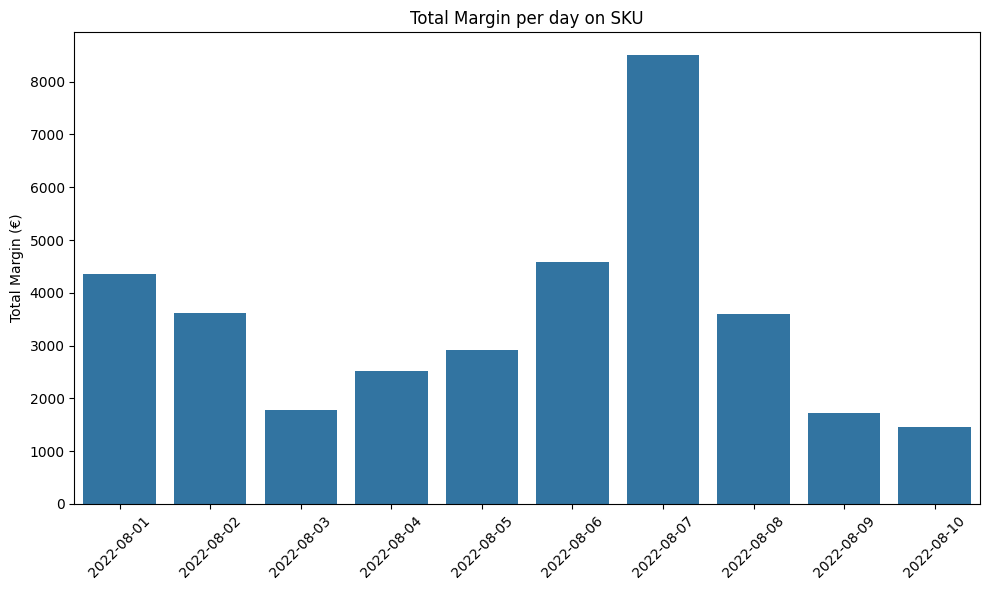

In [89]:
# Plotting
df_margin =  df_margin.sort_values(by='created_at')
plt.figure(figsize=(10, 6))
sns.barplot(data=df_margin, x='created_at', y='total_margin_by_order_details')
plt.title('Total Margin per day on SKU')
plt.xlabel('')
plt.ylabel('Total Margin (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Tax

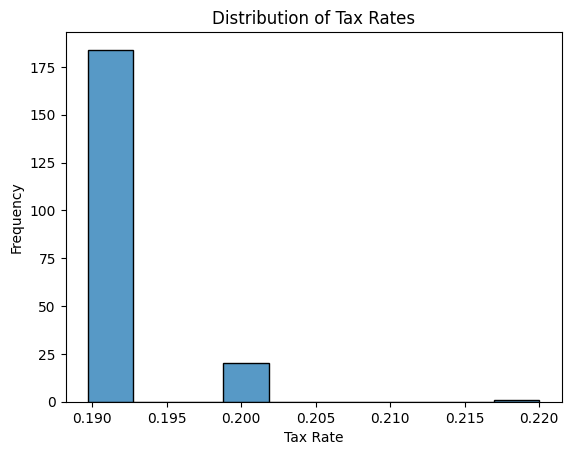

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your tax rate data
tax_rates = [
    0.20008661758336954, 0.20008661758336954, 0.20008661758336954, 0.20007939658594687, 0.20007519268124563,
    0.20007196833393293, 0.20006555944055937, 0.20006555944055937, 0.20006121824303658, 0.20004861448711697,
    0.20002736976553237, 0.20001593117731398, 0.19999999999999996, 0.19999999999999996, 0.19999999999999996,
    0.19047619047619047, 0.19047619047619047, 0.19047619047619047, 0.19047619047619047, 0.19008264462809898,
    0.19007140428425706, 0.19007136859781704, 0.19007136859781704, 0.19007136859781704, 0.19005830378072974,
    0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066,
    0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066,
    0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066,
    0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066,
    0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005261839138066, 0.19005117220040457,
    0.19005117220040457, 0.19004688063469177, 0.19004688063469177, 0.19004688063469177, 0.19004688063469177,
    0.19004688063469177, 0.19004688063469177, 0.19004688063469177, 0.19004688063469177, 0.19004688063469177,
    0.19004688063469177, 0.19004688063469177, 0.19004688063469177, 0.19004477767364358, 0.19004165840111087,
    0.19002773656711613, 0.19002657991827676, 0.19002657991827676, 0.19002473206924986, 0.19002281067142723,
    0.19002065930117662, 0.19001652892561993, 0.19001473421738635, 0.19001451378809864, 0.19001451378809864,
    0.19001396183764374, 0.19001322236913754, 0.19001228345122634, 0.19001108055977345, 0.19000643362642067,
    0.19000643362642067, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895,
    0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895,
    0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000396667988895,
    0.19000396667988895, 0.19000396667988895, 0.19000396667988895, 0.19000280033604056, 0.19000280033604033,
    0.18999999999999995, 0.18999999999999995, 0.18999323867478024, 0.18999168106482367, 0.18999084528532184,
    0.18998735401324107, 0.18998501278321434, 0.18998501278321434, 0.18998501278321434, 0.18998384491114706,
    0.18998370758659755, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666,
    0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666,
    0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666,
    0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666,
    0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666,
    0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18998160770312666, 0.18997170016689657,
    0.18996458087367185, 0.18995993400895594, 0.18995822495467807, 0.18995152049360953, 0.18995152049360953,
    0.18994989684644858, 0.18994496504536662, 0.18991701894473145, 0.18990458602646965, 0.18980963045912658,
    0.2199934945245583, 0.2001058761249339, 0.2000748409629538, 0.2000748409629538, 0.2000748409629538,
    0.2000748409629538, 0.1900564174894217, 0.1900564174894217, 0.1900364797081624, 0.1899923446308025,
    0.1899923446308025, 0.1899923446308025, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777,
    0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777,
    0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777,
    0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899791231732777, 0.1899502177971375,
    0.1899397016820057, 0.1899397016820057, 0.1899397016820057, 0.1899321670831846, 0.1899321670831846,
    0.1899321670831846, 0.1899321670831846, 0.1899321670831846, 0.1899321670831846, 0.1899321670831846,
    0.1899321670831846, 0.1899321670831846, 0.1899321670831846, 0.1899321670831846, 0.1899321670831846,
    0.1899321670831846, 0.1899321670831846, 0.1899321670831846, 0.1899206719552029, 0.1898968526844751,
    0.1897321428571428, 0.1897321428571428, 0.1897321428571428, 0.190087562696591, 0.189979429914781
]

# Create histogram
sns.histplot(tax_rates, bins=10)
plt.xlabel('Tax Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Tax Rates')
plt.show()


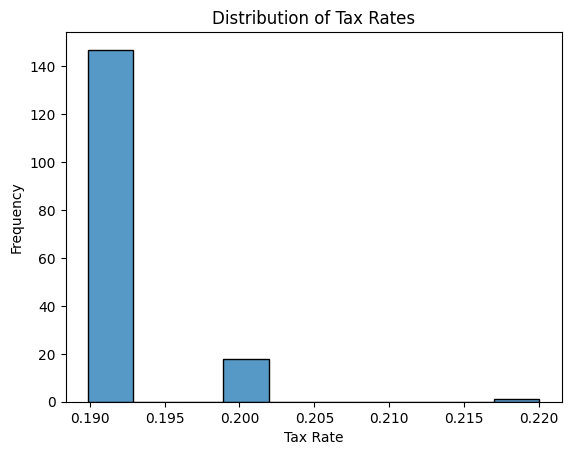

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Provided data
data = [
    0.190014514, 0.190014514, 0.190014514, 0.190014514, 0.189983845, 0.189983845, 0.189983845, 0.189983845,
    0.19002658, 0.19002658, 0.19002658, 0.19002658, 0.19002658, 0.19002658, 0.190011081, 0.190011081,
    0.190011081, 0.190012283, 0.190012283, 0.190012283, 0.190012283, 0.190012283, 0.190012283, 0.189985013,
    0.189985013, 0.189985013, 0.189985013, 0.190020659, 0.190020659, 0.190020659, 0.20002737, 0.20002737,
    0.20002737, 0.20002737, 0.1900028, 0.1900028, 0.1900028, 0.190024732, 0.190024732, 0.190024732, 0.190024732,
    0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.190014734, 0.190014734, 0.190014514, 0.190014514,
    0.189932167, 0.189932167, 0.189932167, 0.189932167, 0.190058304, 0.190058304, 0.200061218, 0.200061218,
    0.189990845, 0.189990845, 0.200075193, 0.200075193, 0.190052618, 0.190052618, 0.190052618, 0.190052618,
    0.190052618, 0.190052618, 0.189991681, 0.189991681, 0.189991681, 0.189991681, 0.189991681, 0.190027737,
    0.190027737, 0, 0.190016529, 0.190016529, 0.190013962, 0.190013962, 0.190013962, 0.190013962,
    0.189992345, 0.189992345, 0.189992345, 0.189992345, 0.189992345, 0.189983708,
    0.189983708, 0.1899717, 0.1899717, 0.18997943, 0.18997943, 0.18997943, 0.18997943, 0.189987354,
    0.189987354, 0.189987354, 0.190013222, 0.190013222, 0.189958225, 0.189958225, 0.189958225, 0.200015931,
    0.200015931, 0.190087563, 0.190087563, 0.190087563, 0.189985013, 0.189985013,
    0.189985013, 0.189985013, 0.200071968, 0.200071968, 0.200071968, 0.200079397, 0.200079397, 0.190022811,
    0.190022811, 0.190041658, 0.190041658, 0.190041658, 0.189904586, 0.189904586, 0, 0, 0,
    0.190044778, 0.190044778, 0.190044778, 0.190071369, 0.190071369, 0.190071369, 0.190071369, 0.190071369,
    0.190071369, 0.219993495, 0.190006434, 0.190006434, 0.190006434, 0.190006434, 0.200086618, 0.200086618,
    0.200086618, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608,
    0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608,
    0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608, 0.189981608,
    0.189981608, 0.189981608, 0.189981608, 0.189981608
]

data = [value for value in data if value != 0]

# Create histogram
sns.histplot(data, bins=10)
plt.xlabel('Tax Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Tax Rates')
plt.show()
